<a href="https://colab.research.google.com/github/kousheel05/TASK_AIML-/blob/main/EV_Analysis_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------INFORMATION-------------------
----------------first 5 rows------------------
  Vehicle_ID Manufacturer          Model Vehicle_Type  Battery_Capacity  \
0      EV001      Hyundai  Kona Electric        Sedan                65   
1      EV002        Tesla        Model 3    Hatchback                57   
2      EV003         Tata       Nexon EV          SUV                50   
3      EV004      Hyundai        Ioniq 5          SUV                74   
4      EV005         Audi      e-tron GT          SUV               103   

   Range  Efficiency  Charging_Time  Top_Speed  Motor_Power    Price  \
0    323        4.97            2.2        146          426  7013171   
1    279        4.89            5.6        170          446  6251625   
2    384        7.68            3.7        159          190  8829685   
3    527        7.12            7.1        237          354  1847117   
4    479        4.65            1.7        178          228  1469343   

   Launch_Year  Safety

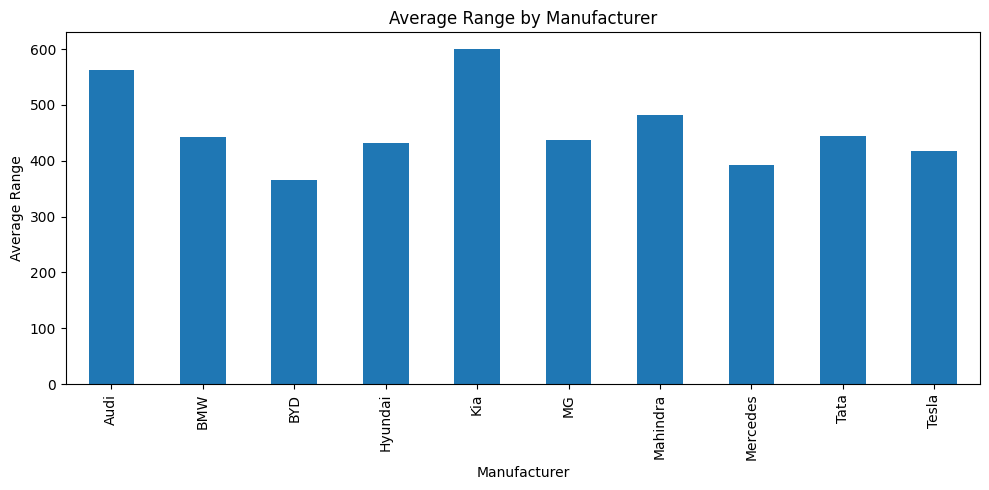

Histogram


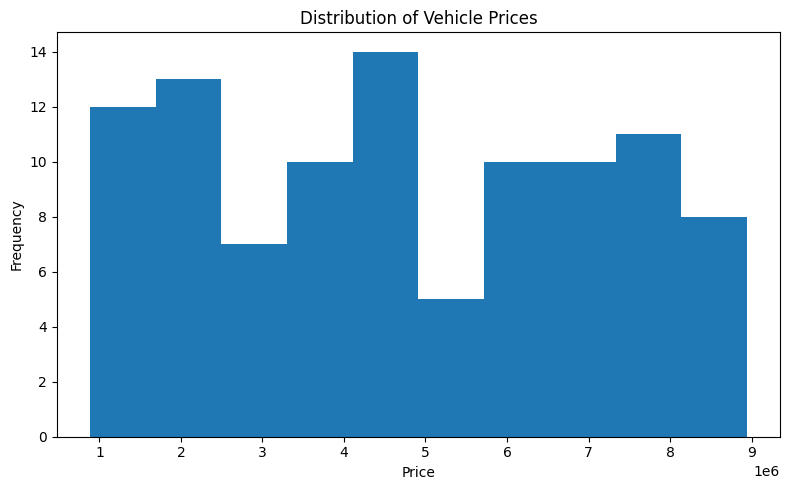

pie chart


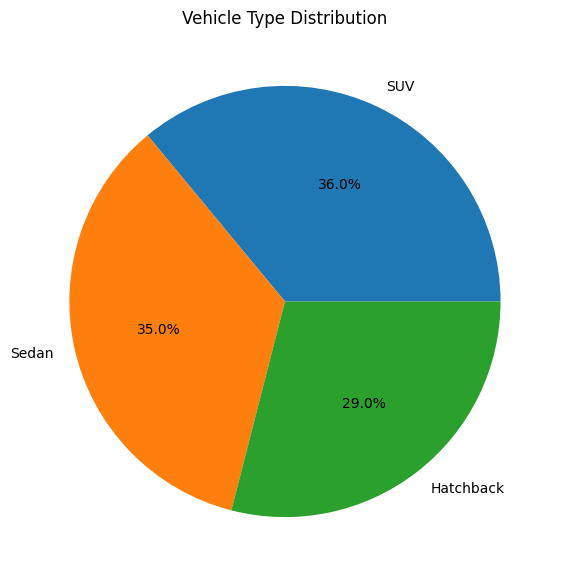

---------------seaborn functions----------------
heat map


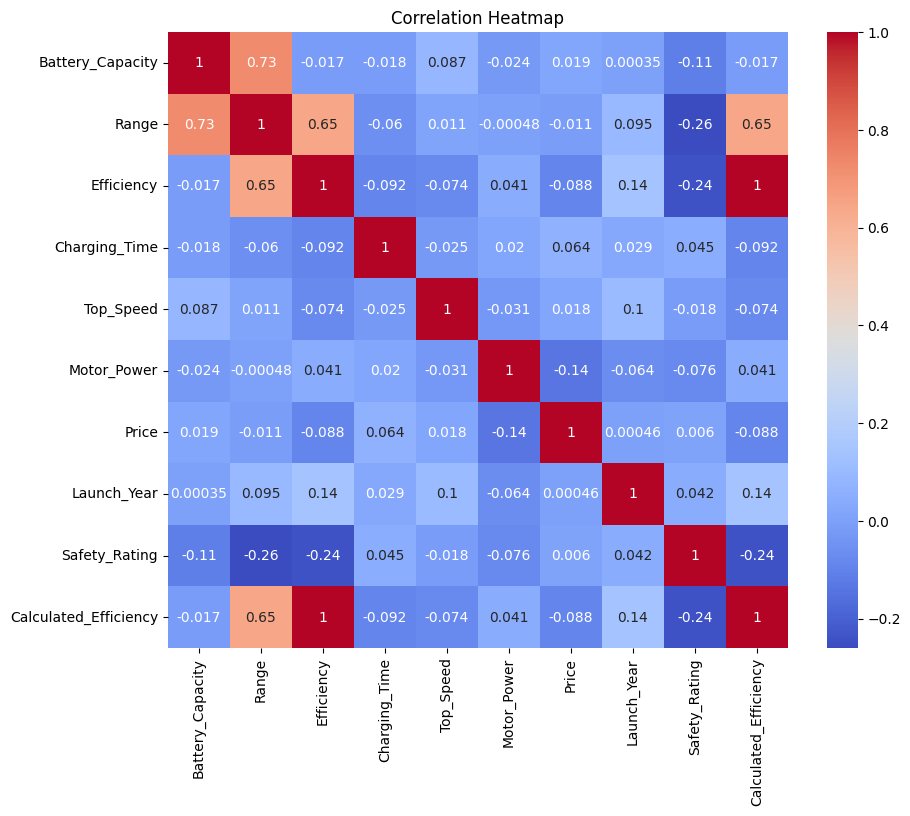

pair plot


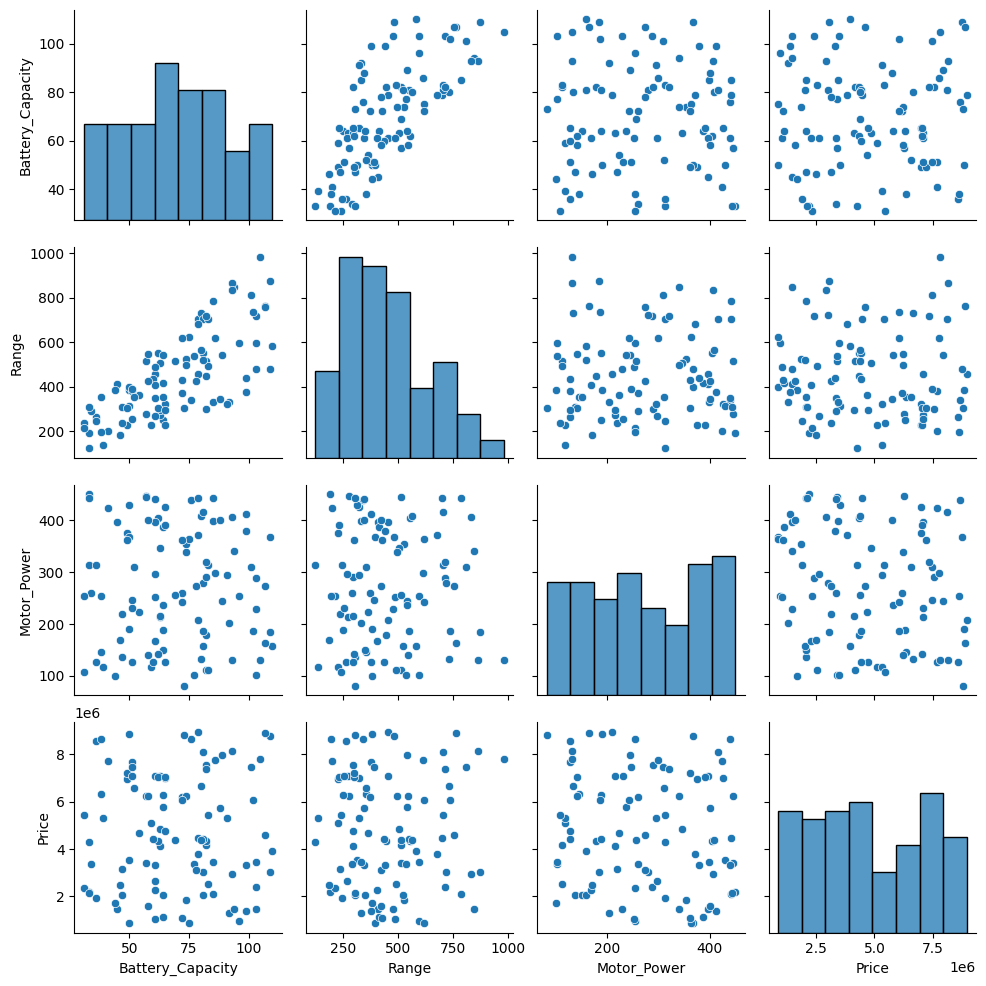

-----------plotly functions----------------


analysis completed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv("EV_Performance_Dataset.csv")
print("----------------INFORMATION-------------------")
print("----------------first 5 rows------------------")
print(df.head())
print("----------------info of dataset---------------")
print(df.info())
print("-----------------missing values----------------")
print(df.isnull())
print("---------------adding all missing values--------")
print(df.isnull().sum())


print("-----------EFFICIENCY CALUCLATION---------------")
def calculate_efficiency(range_km, battery_capacity):
    return round(range_km / battery_capacity, 2)
df["Calculated_Efficiency"] = df.apply(
    lambda x: calculate_efficiency(x["Range"], x["Battery_Capacity"]),
    axis=1
)
print("\nCalculated Efficiency")
print(df[["Vehicle_ID","Calculated_Efficiency"]])




print("------------VECHILE CLASSIFICATION BASED ON EFFICIENCY--------")
def classify_vehicle(efficiency):
    if efficiency > 8:
        return "Excellent"
    elif efficiency >= 6:
        return "Good"
    elif efficiency >= 4:
        return "Average"
    else:
        return "Poor"
df["Efficiency_Category"] = df["Calculated_Efficiency"].apply(classify_vehicle)
print("\nEfficiency Categories")
print(df[["Vehicle_ID","Calculated_Efficiency","Efficiency_Category"]])



filtered = df[
    (df["Range"] > 400) &
    (df["Charging_Time"] < 2) &
    (df["Safety_Rating"] >= 4)
]

print("\nVehicles Matching Conditions")
print(filtered)


print("------------MEAN MAX STD (NUMPY FUNCTIONS----------)")
battery = df["Battery_Capacity"].to_numpy()
vehicle_range = df["Range"].to_numpy()
price = df["Price"].to_numpy()
motor = df["Motor_Power"].to_numpy()
charging = df["Charging_Time"].to_numpy()
print("Mean Battery Capacity :", np.mean(battery))
print("Mean Vehicle Range :", np.mean(vehicle_range))
print("Std Deviation of Prices :", np.std(price))
print("Maximum Motor Power :", np.max(motor))
print("Minimum Charging Time :", np.min(charging))

print("--------------battery vs range----------")
print("Battery Capacity vs Range")
print(np.corrcoef(battery, vehicle_range)[0,1])
print("Price vs Motor Power")
print(np.corrcoef(price, motor)[0,1])
print("Charging Time vs Battery Capacity")
print(np.corrcoef(charging, battery)[0,1])




print("-----------information----------------")
print("Most Expensive Vehicle")
print(df.loc[df["Price"].idxmax()])
print("Cheapest Vehicle")
print(df.loc[df["Price"].idxmin()])
print("Maximum Range Vehicle")
print(df.loc[df["Range"].idxmax()])
print("Highest Efficiency Vehicle")
print(df.loc[df["Calculated_Efficiency"].idxmax()])
print("Manufacturer Wise Statistics")
manufacturer_stats = df.groupby("Manufacturer").agg({
    "Price":"mean",
    "Range":"mean",
    "Battery_Capacity":"mean"
}).round(2)
print(manufacturer_stats)

print("---------ploting using matplotlib------------")
print("bar chart")
plt.figure(figsize=(10,5))
manufacturer_stats["Range"].plot(kind="bar")
plt.title("Average Range by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Average Range")
plt.tight_layout()
plt.show()
print("Histogram")
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=10)
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("pie chart")
plt.figure(figsize=(7,7))

df["Vehicle_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Vehicle Type Distribution")
plt.ylabel("")
plt.show()
print("---------------seaborn functions----------------")
print("heat map")
plt.figure(figsize=(10,8))
numeric = df.select_dtypes(include=np.number)
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()
print("pair plot")
sns.pairplot(
    df[[
        "Battery_Capacity",
        "Range",
        "Motor_Power",
        "Price"
    ]]
)
plt.show()
print("-----------plotly functions----------------")
fig = px.scatter(
    df,
    x="Battery_Capacity",
    y="Range",
    color="Manufacturer",
    size="Price",
    hover_name="Model",
    title="Battery Capacity vs Range"
)
fig.show()

print("analysis completed")
df.to_csv("EV_Performance_Dataset_Analyzed.csv", index=False)
from google.colab import files
files.download("EV_Performance_Dataset_Analyzed.csv")

In [34]:
manufacturers = ["All"] + sorted(df["Manufacturer"].unique())

fig = px.scatter(

    df,

    x="Battery_Capacity",

    y="Range",

    color="Manufacturer",

    size="Price",

    hover_name="Model",

    title="Manufacturer Filter"

)

buttons = []

buttons.append(

    dict(

        label="All",

        method="update",

        args=[

            {"visible":[True]*len(fig.data)},

            {"title":"All Manufacturers"}

        ]

    )

)

for manufacturer in sorted(df["Manufacturer"].unique()):

    visibility = []

    for trace in fig.data:

        visibility.append(trace.name == manufacturer)

    buttons.append(

        dict(

            label=manufacturer,

            method="update",

            args=[

                {"visible":visibility},

                {"title":manufacturer}

            ]

        )

    )

fig.update_layout(

    updatemenus=[

        dict(

            buttons=buttons,

            direction="down",

            x=1.15,

            y=1

        )

    ]

)

fig.show()